# 01 - Exploratory Consumption Analysis

This notebook explores the synthetic household electricity consumption dataset used in the project.

The goal is to understand:

- Hourly consumption patterns
- Daily consumption variation
- Average consumption by hour of day
- Differences between weekdays and weekends

This exploratory analysis is the first step before simulating solar generation, battery storage and economic optimization.

In [ ]:
from pathlib import Path
import sys


import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

from data_loader import load_consumption_data

DATA_PATH = PROJECT_ROOT / "data" / "simulated" / "synthetic_consumption_30_days.csv"

## Load data

We load the synthetic 30-day household electricity consumption dataset.

In [6]:
df = load_consumption_data(str(DATA_PATH))

df.head()

,datetime,consumption_kwh,hour,day,month,weekday
0,2025-01-01 00:00:00,0.108107,0,1,1,2
1,2025-01-01 01:00:00,0.178394,1,1,1,2
2,2025-01-01 02:00:00,0.143866,2,1,1,2
3,2025-01-01 03:00:00,0.130514,3,1,1,2
4,2025-01-01 04:00:00,0.204402,4,1,1,2


## Basic dataset information

The dataset contains hourly electricity consumption values.

In [7]:
print(f"Number of rows: {len(df)}")
print(f"Start datetime: {df['datetime'].min()}")
print(f"End datetime: {df['datetime'].max()}")
print(f"Total consumption: {df['consumption_kwh'].sum():.2f} kWh")
print(f"Average hourly consumption: {df['consumption_kwh'].mean():.3f} kWh")
print(f"Maximum hourly consumption: {df['consumption_kwh'].max():.3f} kWh")
print(f"Minimum hourly consumption: {df['consumption_kwh'].min():.3f} kWh")

Number of rows: 720
Start datetime: 2025-01-01 00:00:00
End datetime: 2025-01-30 23:00:00
Total consumption: 229.66 kWh
Average hourly consumption: 0.319 kWh
Maximum hourly consumption: 0.793 kWh
Minimum hourly consumption: 0.050 kWh


## Hourly consumption over time

This plot shows the hourly electricity consumption over the full simulated period.

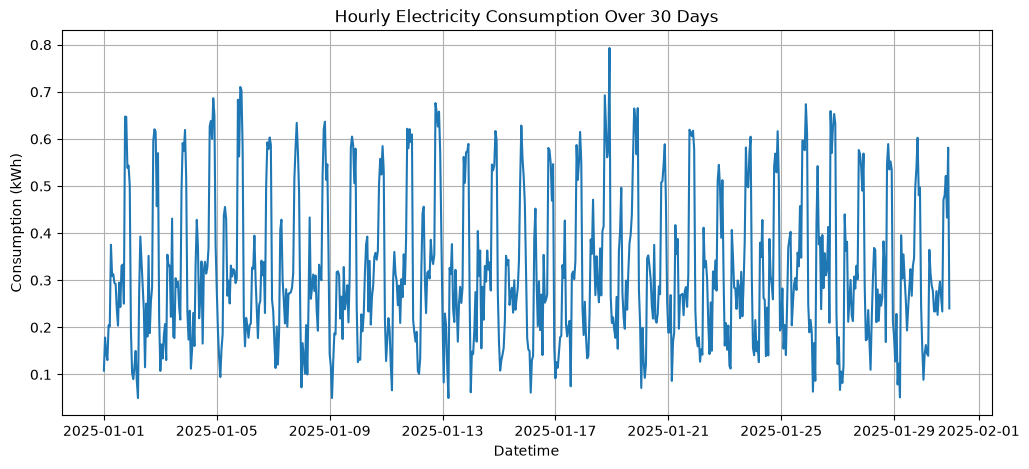

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(df["datetime"], df["consumption_kwh"])

plt.title("Hourly Electricity Consumption Over 30 Days")
plt.xlabel("Datetime")
plt.ylabel("Consumption (kWh)")
plt.grid(True)

plt.show()

## Daily consumption

We aggregate hourly consumption into daily totals.

In [9]:
daily_consumption = (
    df.groupby(df["datetime"].dt.date)["consumption_kwh"].sum().reset_index()
)

daily_consumption.columns = ["date", "daily_consumption_kwh"]

daily_consumption.head()

,date,daily_consumption_kwh
0,2025-01-01,7.513452
1,2025-01-02,6.824298
2,2025-01-03,7.319526
3,2025-01-04,8.432726
4,2025-01-05,8.524269


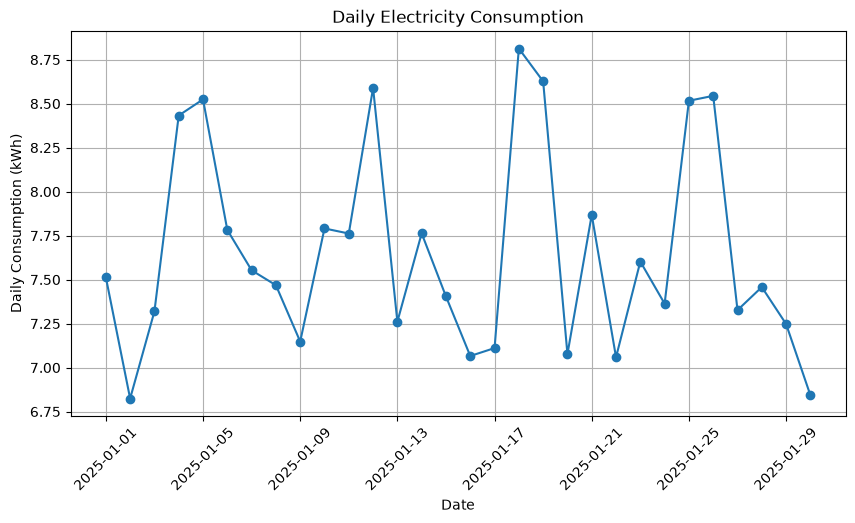

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_consumption["date"], daily_consumption["daily_consumption_kwh"], marker="o"
)

plt.title("Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Daily Consumption (kWh)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Average consumption by hour of day

This plot shows the average household consumption pattern across a typical day.

In [11]:
average_by_hour = df.groupby("hour")["consumption_kwh"].mean().reset_index()

average_by_hour.head()

,hour,consumption_kwh
0,0,0.161523
1,1,0.164809
2,2,0.161976
3,3,0.146157
4,4,0.157957


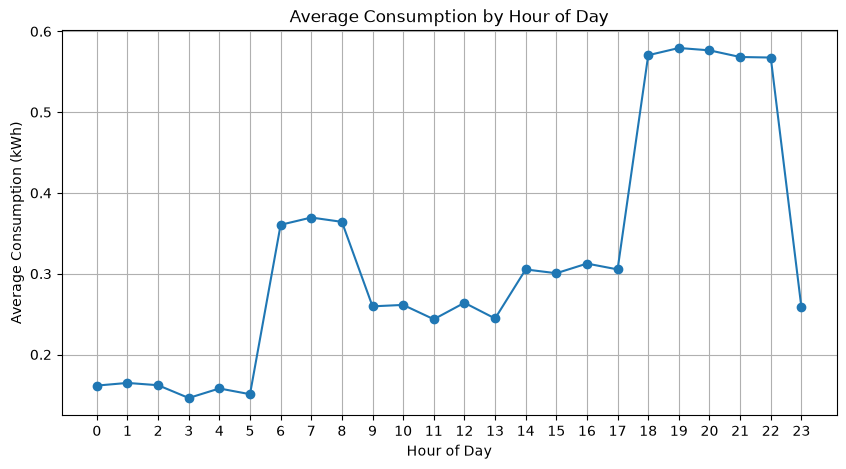

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(average_by_hour["hour"], average_by_hour["consumption_kwh"], marker="o")

plt.title("Average Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (kWh)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

## Average consumption by weekday

We compare the average hourly consumption depending on the day of the week.

In [13]:
weekday_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

df["weekday_name"] = df["weekday"].map(weekday_names)

average_by_weekday = (
    df.groupby(["weekday", "weekday_name"])["consumption_kwh"].mean().reset_index()
)

average_by_weekday

,weekday,weekday_name,consumption_kwh
0,0,Monday,0.306732
1,1,Tuesday,0.319188
2,2,Wednesday,0.305775
3,3,Thursday,0.295700
4,4,Friday,0.308176
5,5,Saturday,0.349215
6,6,Sunday,0.357137


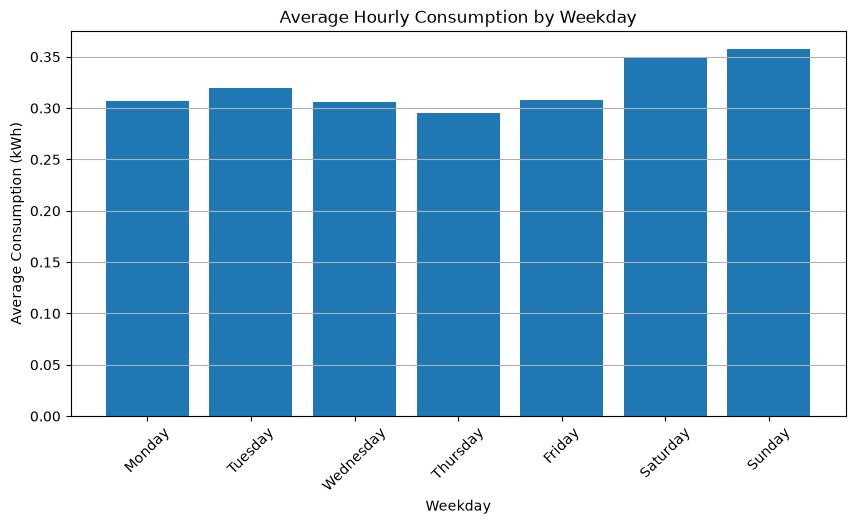

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(average_by_weekday["weekday_name"], average_by_weekday["consumption_kwh"])

plt.title("Average Hourly Consumption by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Consumption (kWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## Conclusions

The synthetic dataset shows a realistic daily electricity consumption pattern:

- Lower consumption during the night
- Higher consumption during morning and evening periods
- Slightly higher consumption during weekends
- Stable but variable daily electricity demand

This dataset is suitable for testing the solar generation, battery storage and economic optimization modules of the project.